In [ ]:
# Import library
import tensorflow as tf # TensorFlow: build and train a model
print("TensorFlow version:", tf.__version__)

import numpy as np #numerical operations
import matplotlib.pyplot as plt #visualize img and graphics
import os #folders
# Metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, auc, roc_curve
#to use modelcheckpoint
from keras.callbacks import ModelCheckpoint
#others:
import pandas as pd

import keras
from keras import layers #to create layers of the model
print(keras.__version__)

import seaborn as sns
import json
import shutil

import sklearn
print(sklearn.__version__)

from keras.applications.resnet import preprocess_input

TensorFlow version: 2.20.0
3.13.2
1.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#create folder structure for results history
BASE_PATH = "/content/drive/MyDrive/resultsResnetOPT1"
print(BASE_PATH) #if the path is correct

folders = [
    "models",
    "histories",
    "metrics",
    "plots/training",
    "plots/confusion_matrix",
    "plots/roc"
]

for f in folders:
    os.makedirs(os.path.join(BASE_PATH, f), exist_ok=True)


#check dirive si correctly implemented
print(os.listdir("/content/drive/MyDrive"))
#check the path
print(os.listdir(BASE_PATH)) #if it exists

/content/drive/MyDrive/resultsResnetOPT1
['Colab Notebooks', 'kaggle', 'results5', 'results10', 'resultsResnetOPT1', 'resultsVgg16DensenetOPT1', 'GradCam']
['models', 'histories', 'metrics', 'plots']


In [ ]:
# dataset folders directions
TRAIN_DIR = "/content/drive/MyDrive/kaggle/train"
TEST_DIR  = "/content/drive/MyDrive/kaggle/test"


#upload dataset

#define img sizes and batch sizes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # 32= small batch ->indirectly helps against ovefitting

#train dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",          # takes labels from folders
    label_mode="binary",        # binary classification
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
#test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

#check labels
class_names = train_ds.class_names
print("Class:", class_names)

Found 2637 files belonging to 2 classes.
Found 660 files belonging to 2 classes.
Class: ['benign', 'malignant']


Normalization & data augmentation

In [ ]:
#OPT. different normalization to train and test dataset for resnet
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))




#define fz for data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])
#apply data augm
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

#fz early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

CREATE VALIDATION DATASET (from training dataset)

In [ ]:
#split validation = 20% of train dataset
train_size = int(0.8 * tf.data.experimental.cardinality(train_ds).numpy()) #define size of train = 0,8 of the tot train_img

train_ds_split = train_ds.take(train_size) #new train dataset= 0,8 original train dataset
val_ds_split   = train_ds.skip(train_size) #validation dataset= 0,2 original train dataset

BUILD MODEL:
1) takes a CNN pre-trained (vg16, ResNet, DenseNet)
2) removes the original classificator of the model
3) block weight pre-trained
4) add a new classificator and adapt the algoritm to binary problem (benign vs melanoma malignant)


In [ ]:
#build model
def build_model(model_name):

    if model_name == "vgg16": #famous CNN: easy but powerful
        base_model = keras.applications.VGG16(
            weights="imagenet", #uses weight already trained on millions images
            include_top=False, #delate the last layer of clasification
            input_shape=(224,224,3) #img 224*224 RGB (3 colors)
        )

    elif model_name == "resnet": #resnet uses skip connection (deeper)
        base_model = keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "densenet": #more advanced: every layer connected to the following
        base_model = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    # OPT. Fine tuning: learning specific features
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    #define of the imput imgs shapes: 224x224, RGB (3 colors)
    inputs = keras.Input(shape=(224,224,3))

    # oss. 'x' represent the input data in the model that changes step by step during the different passages of the model

    x = base_model(inputs, training=False) #  l'immagine passa attraverso i modelli: vgg16/DenseNet/ResNet
    #training=false: use fix weights
    #training=true: update weights

    x = layers.GlobalAveragePooling2D()(x) #pooling layer: from 2D matrix to vector 512
    x = layers.Dense(128, activation="relu")(x) #classification layer
    x = layers.Dropout(0.5)(x) #to avoid overfitting

    outputs = layers.Dense(1, activation="sigmoid")(x) #sigmoid gives probability output [0,1]
    # ouput 0=benign, 1=melanoma malignant

    #build the funcion model that takes the imgs input and gives a probability of a class as an output
    model = keras.Model(inputs, outputs) #imput ->network(layer->layer->layer->) -> output

    #optimizer
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-4 #OPT. LEARNING RATE lower
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    #return model ready for training
    return model


TRAINING: initial weights form ImageNet.

In [ ]:
EPOCHS = 10

history_dict = {}
results = {}

for name in ["resnet"]:
    print(f"\nTraining {name}")

    model = build_model(name) #create the model: output= probability benign vs malignant

    # create folders on drive
    os.makedirs(os.path.join(BASE_PATH, "models"), exist_ok=True) #exist_ok=true: doesn't crush if folder already exists
    os.makedirs(os.path.join(BASE_PATH, "histories"), exist_ok=True)

    #chekpoint_path
    checkpoint_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")

    # checkpoint (salva solo il migliore modello)
    #oss. salva il modello solo quando la val_loss migliora, altrimenti potrei salvare anche se va in overfitting :/
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path, #where it save the model
        monitor="val_loss", #check loss of validation
        save_best_only=True, #saves only if it gets better
        mode="min",
        verbose=1 #stamp when saves
    )

    #TRAINING
    #OPT. early stopping
    history = model.fit(
        train_ds_split,
        validation_data=val_ds_split,
        epochs=EPOCHS,
        callbacks=[checkpoint, early_stopping]
    )

    #SAVE HISTORY
    history_path = os.path.join(BASE_PATH, "histories", f"{name}_history.json") #history path

    with open(history_path, "w") as f:
        json.dump(history.history, f, indent=4) #saves history on files:
                                                #vgg16_history.json,resnet_history.json, densenet_history.json
    #oss. in histoy.histoy there are: {"loss": [...],"accuracy": [...], "val_loss": [...], "val_accuracy": [...]}

    history_dict[name] = history.history # store in dictionary (useful for quick plotting)



Training resnet
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7540 - loss: 0.5150
Epoch 1: val_loss improved from None to 0.36495, saving model to /content/drive/MyDrive/resultsResnetOPT1/models/resnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/resultsResnetOPT1/models/resnet_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 829s 12s/step - accuracy: 0.8087 - loss: 0.4093 - val_accuracy: 0.8686 - val_loss: 0.3650
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8647 - loss: 0.2855
Epoch 2: val_loss did not improve from 0.36495
66/66 ━━━━━━━━━━━━━━━━━━━━ 758s 11s/step - accuracy: 0.8707 - loss: 0.2686 - val_accuracy: 0.8857 - val_loss: 0.3675
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9172 - loss: 0.2104 
Epoch 3: val_loss improved from 0.36495 to 0.25136, saving model to /content/drive/MyDrive/resultsResnetOPT1/models/resnet_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/resultsResnetOPT1/models/r

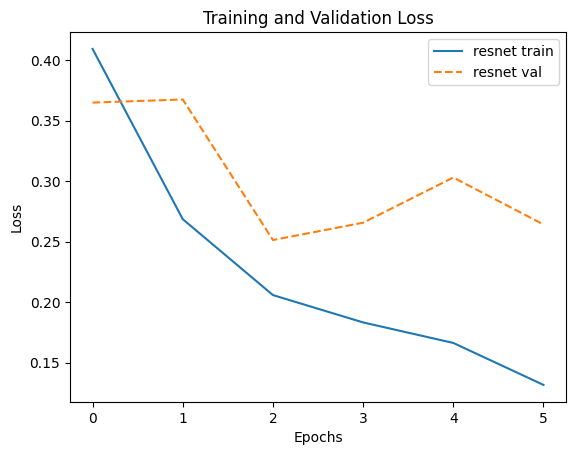

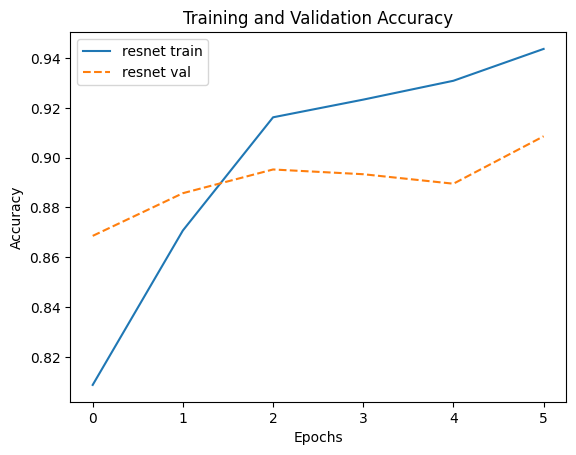

In [ ]:
models = ["resnet"]
history_dict = {} #dictionary where i save all the historys

# load history from drive
for name in models:
    history_path = os.path.join(BASE_PATH, "histories", f"{name}_history.json") #build file path

#open file json, read it, convert it in python, save it in history_dict
    with open(history_path, "r") as f:
        history_dict[name] = json.load(f)


#PLOT LOSS
plt.figure() #create a new empty figure

for name in models:
    plt.plot(history_dict[name]["loss"], label=f"{name} train") #training loss: solid line
    plt.plot(history_dict[name]["val_loss"], linestyle="--", label=f"{name} val") #validation loss: dashed line

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

#save in drive
loss_plot_path = os.path.join(BASE_PATH, "plots", "training", "loss_plot.png") #create path on drive
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight") #savefig: save graphic, dpi=300: high quality, "tight" delete empty points

plt.show() #show graphic
 #train loss ↓ =the model is learning
 # val loss ↓ = model generalise correctly
 #val loss ↑ while tain loss ↓ = overfitting


#ACCURACY PLOT
plt.figure()

for name in models:
    plt.plot(history_dict[name]["accuracy"], label=f"{name} train")
    plt.plot(history_dict[name]["val_accuracy"], linestyle="--", label=f"{name} val")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

#save in drive
acc_plot_path = os.path.join(BASE_PATH, "plots", "training", "accuracy_plot.png") #create path on drive
plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")

plt.show()
#accuracy ↑ = model is getting better
#gap train vs val = overfitting
#similar graphic curves = good generalization

TEST

PLOT METRICS to compare performance

        accuracy  sensitivity  specificity        f1       auc
resnet  0.877273         0.85          0.9  0.862944  0.958259


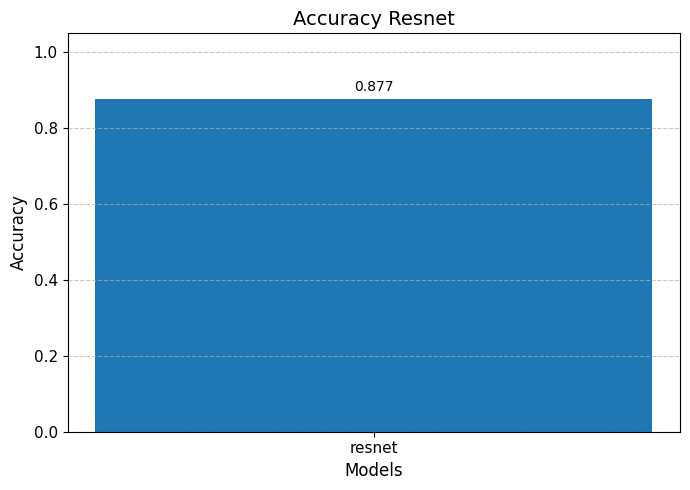

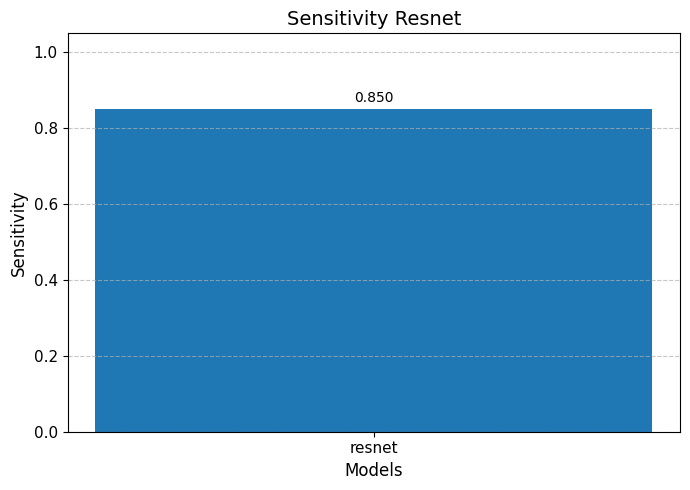

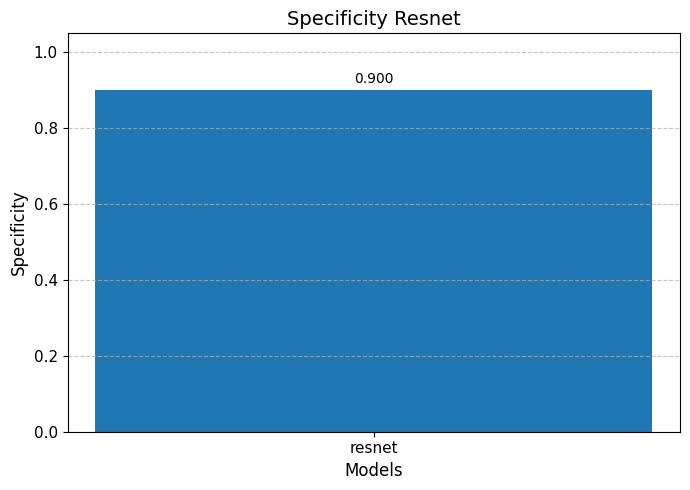

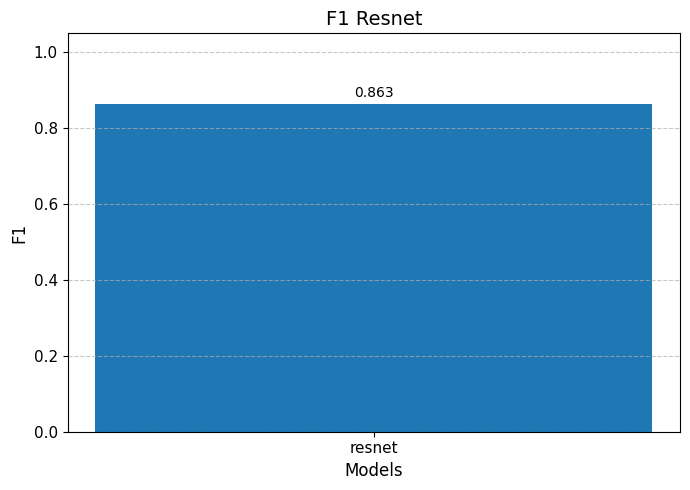

In [ ]:
# LOAD FINAL METRICS
results_path = os.path.join(BASE_PATH, "metrics", "final_results.csv")
df = pd.read_csv(results_path, index_col=0)
print(df)

# CREATE COMPARISON GRAPHS
metrics_list = ["accuracy", "sensitivity", "specificity", "f1"]
os.makedirs(os.path.join(BASE_PATH, "plots", "metrics"), exist_ok=True) #create path

for metric in metrics_list:

    # larger figure for thesis quality
    plt.figure(figsize=(7,5))

    # bar plot
    bars = plt.bar(df.index, df[metric])

    # titles and labels
    plt.title(f"{metric.capitalize()} Resnet", fontsize=14)
    plt.xlabel("Models", fontsize=12)
    plt.ylabel(metric.capitalize(), fontsize=12)

    # better axis scale
    plt.ylim(0, 1.05)

    # improve ticks
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    # values above bars
    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            fontsize=10
        )

    # horizontal grid only
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # automatically fix layout problems
    plt.tight_layout()

    # save plot
    save_path = os.path.join(
        BASE_PATH,
        "plots",
        "metrics",
        f"{metric}_comparison.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

ROC CURVE GRAPHIC (false positive vs sensitivity)


Generating ROC for resnet


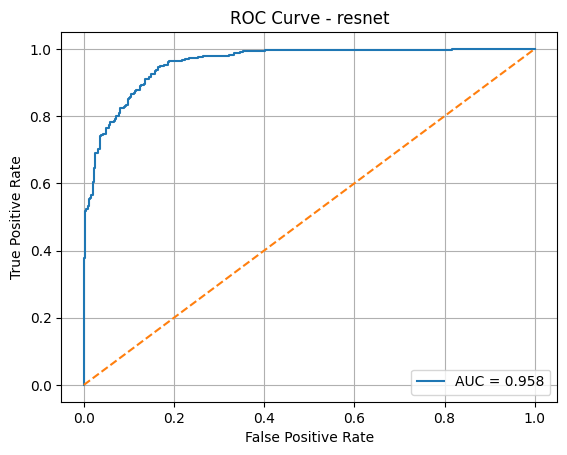

ROC data saved to: /content/drive/MyDrive/resultsResnetOPT1/metrics/roc_data.json


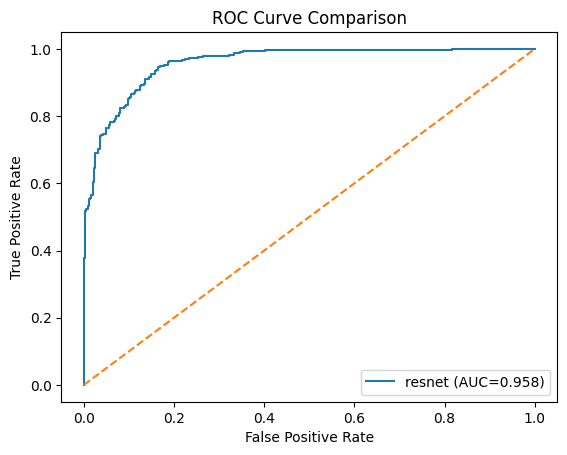

In [ ]:
# Diagonal line: causal model
# Line close to the left upper part: good model


#CREATE FUNCTION ROC CURVE that:
#takes model->test dataset-> create ROC-curve
def plot_roc(model, dataset, name):

    y_true = [] #real label
    y_pred = [] #probability

    # collect predictions
    for x, y in dataset:
        preds = model(x, training=False).numpy() #gives prbability [0,1]

        y_true.extend(y.numpy().flatten()) #list of true label
        y_pred.extend(preds.flatten()) #list of predictions

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr) #global metric: 1=perfect, 0.5=random, <0.5=terrible
    #FPR=False Positive Rate
    #TPR= True Positive Rate/sensibility

    # PLOT
    plt.figure()

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}") #roc curve
    plt.plot([0, 1], [0, 1], linestyle="--") #random baseline

    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.legend()

    # SAVE img
    save_path = os.path.join(BASE_PATH, "plots", "roc", f"{name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fpr, tpr, roc_auc

# LOOP MODELS + SAVE DATA FOR COMPARISON
models = ["resnet"]
roc_data = {}

for name in models:
    print(f"\nGenerating ROC for {name}")

    model_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")
    model = keras.models.load_model(model_path)

    fpr, tpr, roc_auc = plot_roc(model, test_ds, name)

    roc_data[name] = { #raccolta dati per confronto
        "fpr": fpr.tolist(),   # impo conversation
        "tpr": tpr.tolist(),   # JSON dosen't support array numpy
        "auc": float(roc_auc)
    }

# SAVE ROC DATA
roc_data_path = os.path.join(BASE_PATH, "metrics", "roc_data.json")

with open(roc_data_path, "w") as f:
    json.dump(roc_data, f, indent=4)

print("ROC data saved to:", roc_data_path)


# COMPARISON PLOT (ALL MODELS)
plt.figure()

for name in models: #all curves in a single plot
    plt.plot(
        roc_data[name]["fpr"],
        roc_data[name]["tpr"],
        label=f"{name} (AUC={roc_data[name]['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

comparison_path = os.path.join(BASE_PATH, "plots", "roc", "roc_comparison.png")
plt.savefig(comparison_path, dpi=300, bbox_inches="tight")

plt.show()

CONFUSION MATRIX GRAPHIC


Generating Confusion Matrix for resnet


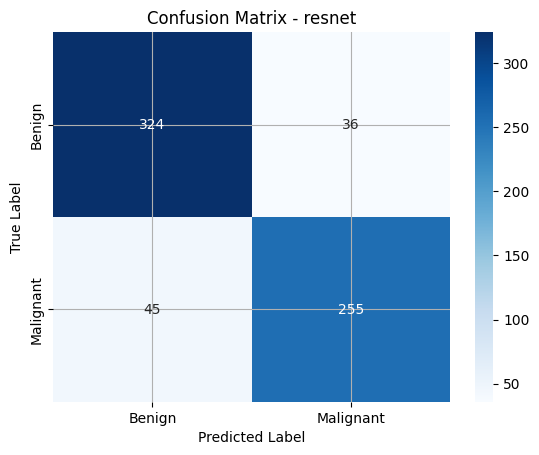

In [ ]:
#Confusion matrix graphic

#function for confusion matrix:
#take model->test>build confusion matrix->save it as img
def plot_cm(model, dataset, name):

    y_true = []
    y_pred = []

    # generate predictions
    for x, y in dataset: #x=img, y=true label
        preds = model(x, training=False).numpy() #give probability [0,1]

        y_true.extend(y.numpy()) #real label
        y_pred.extend(preds.flatten()) #probability

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # probability -> class predictionon
    y_bin = (y_pred > 0.5).astype(int)
    # confusion matrix (2x2 matrix)
    cm = confusion_matrix(y_true, y_bin)

    # PLOT
    plt.figure()

    sns.heatmap(
        cm,
        annot=True, #show numbers
        fmt="d", #formato intero
        cmap="Blues",#readables colors
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.grid(True)

    # SAVE to drive
    save_path = os.path.join(BASE_PATH, "plots", "confusion_matrix", f"{name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight") #300=high quality, "tight"=clean format

    plt.show()



# LOAD MODELS + CM
models = ["resnet"]

#for all models:
#load best model->CM->save in drive
for name in models:
    print(f"\nGenerating Confusion Matrix for {name}")

    # load best model
    model_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")
    model = keras.models.load_model(model_path)

    # plot confusion matrix
    plot_cm(model, test_ds, name)

Grad-CAM

In [ ]:
import os, numpy as np, pandas as pd, tensorflow as tf, matplotlib.pyplot as plt, matplotlib.cm as cm
from tensorflow import keras

# CONFIG
BASE_PATH = "/content/drive/MyDrive/resultsResnetOPT1"
MODEL_PATH = os.path.join(BASE_PATH, "models", "resnet_best.keras")
TEST_DIR = "/content/drive/MyDrive/kaggle/test"
SAVE_ROOT = "/content/drive/MyDrive/GradCam/OPTResnet"
os.makedirs(SAVE_ROOT, exist_ok=True)
IMG_SIZE = (224, 224)
N_IMAGES_PER_CLASS = 10
THRESHOLD = 0.5
USE_RESCALE_01 = True

# LOAD MODEL
print("\nLoading model...")
model = keras.models.load_model(MODEL_PATH)
print("[OK] Model loaded")

# BACKBONE & LAYERS
backbone = model.get_layer("resnet50")
LAST_CONV_LAYER_NAME = "conv5_block3_out"
print("\nBackbone:", backbone.name)
print("Last conv layer:", LAST_CONV_LAYER_NAME)
last_conv_layer = backbone.get_layer(LAST_CONV_LAYER_NAME)

# FEATURE EXTRACTOR
feature_extractor = keras.Model(inputs=backbone.input, outputs=last_conv_layer.output)

# CLASSIFIER HEAD
classifier_input = keras.Input(shape=last_conv_layer.output.shape[1:])
x = classifier_input
x = model.get_layer("global_average_pooling2d_2")(x)
x = model.get_layer("dense_4")(x)
x = model.get_layer("dropout_2")(x)
classifier_output = model.get_layer("dense_5")(x)
classifier_model = keras.Model(classifier_input, classifier_output)
print("[OK] Feature extractor created")
print("[OK] Classifier head created")

# LOAD FIRST N IMAGES FROM CLASS
def load_first_n_from_class(test_dir, class_name, n=10):
    class_dir = os.path.join(test_dir, class_name)
    files = sorted([os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])[:n]
    imgs = []
    for f in files:
        img = keras.utils.load_img(f, target_size=IMG_SIZE)
        img = keras.utils.img_to_array(img).astype("float32")
        if USE_RESCALE_01: img = img / 255.0
        imgs.append((img, f))
    return imgs

# PREDICTION
def predict_binary(model, img, threshold=0.5):
    img_batch = np.expand_dims(img, axis=0).astype(np.float32)
    prob = float(model.predict(img_batch, verbose=0)[0][0])
    pred_label = 1 if prob > threshold else 0
    pred_class = "malignant" if pred_label == 1 else "benign"
    return prob, pred_label, pred_class

# OUTCOME LABEL
def get_outcome_label(true_class, pred_label):
    true_label = 1 if true_class == "malignant" else 0
    if true_label == 0 and pred_label == 0: return "TN"
    elif true_label == 0 and pred_label == 1: return "FP"
    elif true_label == 1 and pred_label == 0: return "FN"
    elif true_label == 1 and pred_label == 1: return "TP"

# MAKE GRAD-CAM HEATMAP
def make_gradcam_heatmap(img_array):
    if img_array.ndim == 3: img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs = feature_extractor(img_array, training=False)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs, training=False)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    if grads is None: raise RuntimeError("Gradients are None")
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# OVERLAY HEATMAP
def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], img.shape[:2]).numpy().squeeze()
    heatmap_color = cm.get_cmap("jet")(heatmap_resized)[..., :3]
    overlay = np.clip((1-alpha) * img + alpha * heatmap_color, 0, 1)
    return heatmap_resized, overlay

# SAVE GRAD-CAM PANEL
def save_gradcam_panel(img, heatmap, overlay, save_path, title_text):
    fig, ax = plt.subplots(1, 3, figsize=(12,4))
    ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(heatmap, cmap="jet"); ax[1].set_title("Heatmap"); ax[1].axis("off")
    ax[2].imshow(overlay); ax[2].set_title("Overlay"); ax[2].axis("off")
    fig.suptitle(title_text, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# SAVE SINGLE OUTPUTS
def save_single_outputs(img, heatmap, overlay, out_dir, base_name, title_text):
    os.makedirs(out_dir, exist_ok=True)
    original_path = os.path.join(out_dir, f"{base_name}_original.png")
    heatmap_path = os.path.join(out_dir, f"{base_name}_heatmap.png")
    overlay_path = os.path.join(out_dir, f"{base_name}_overlay.png")
    panel_path = os.path.join(out_dir, f"{base_name}_panel.png")
    plt.imsave(original_path, img)
    plt.imsave(heatmap_path, heatmap, cmap="jet")
    plt.imsave(overlay_path, overlay)
    save_gradcam_panel(img, heatmap, overlay, panel_path, title_text)
    return original_path, heatmap_path, overlay_path, panel_path

# RUN GRAD-CAM
rows = []
for true_class in ["benign", "malignant"]:
    print(f"\nProcessing class: {true_class}")
    samples = load_first_n_from_class(TEST_DIR, true_class, n=N_IMAGES_PER_CLASS)
    for i, (img, img_path) in enumerate(samples, start=1):
        print(f"Image {i}/{N_IMAGES_PER_CLASS}")
        prob, pred_label, pred_class = predict_binary(model, img, threshold=THRESHOLD)
        outcome = get_outcome_label(true_class, pred_label)
        heatmap = make_gradcam_heatmap(img)
        heatmap_resized, overlay = overlay_heatmap(img, heatmap, alpha=0.4)
        out_dir = os.path.join(SAVE_ROOT, outcome, true_class)
        base_name = f"{true_class}_{i:02d}"
        title_text = f"RESNET OPTIMIZED | True: {true_class} | Pred: {pred_class} | Outcome: {outcome} | P(malignant)={prob:.4f}"
        original_path, heatmap_path, overlay_path, panel_path = save_single_outputs(img, heatmap_resized, overlay, out_dir, base_name, title_text)
        rows.append({
            "true_class": true_class, "pred_class": pred_class, "pred_prob_malignant": prob,
            "pred_label": pred_label, "outcome": outcome, "sample_index": i,
            "filename": os.path.basename(img_path), "full_path": img_path,
            "last_conv_layer": LAST_CONV_LAYER_NAME,
            "original_path": original_path, "heatmap_path": heatmap_path,
            "overlay_path": overlay_path, "panel_path": panel_path
        })

# SAVE CSV
df = pd.DataFrame(rows)
csv_path = os.path.join(SAVE_ROOT, "resnet_optimized_gradcam_results.csv")
df.to_csv(csv_path, index=False)
print("\nDetailed CSV saved:")
print(csv_path)

# SUMMARY
summary_counts = df["outcome"].value_counts().to_dict()
summary_df = pd.DataFrame([summary_counts]).fillna(0)
summary_path = os.path.join(SAVE_ROOT, "resnet_optimized_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("\nSummary CSV saved:")
print(summary_path)
print("\nOutcome summary:")
print(summary_df)
print("\nDONE.")

Output hidden; open in https://colab.research.google.com to view.